In [1]:

!export PATH="/mnt/data/liushiyu/miniforge3/bin:$PATH"
!export CUDA_VISIBLE_DEVICES=0
!export HF_ENDPOINT='https://hf-mirror.com'
!export HF_HOME="/mnt/gptdata/liushiyu/flow_matching_pytorch_lucidrains/large_files/hf-cache"
!export CUDA_HOME="/mnt/gptdata/liushiyu/cuda_tools/local_cuda"
exp_name="exp_adni.latent"
!mkdir /mnt/gptdata/liushiyu/flow_matching_pytorch_lucidrains/large_files/{exp_name}
!ln -s ./{exp_name} /mnt/gptdata/liushiyu/flow_matching_pytorch_lucidrains/large_files/{exp_name}
import os 
os.environ["CUDA_VISIBLE_DEVICES"]="3"
!nvidia-smi

mkdir: cannot create directory '/mnt/gptdata/liushiyu/flow_matching_pytorch_lucidrains/large_files/exp_adni.latent': File exists
ln: failed to create symbolic link '/mnt/gptdata/liushiyu/flow_matching_pytorch_lucidrains/large_files/exp_adni.latent/exp_adni.latent': File exists
Wed Sep 10 09:52:45 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.06             Driver Version: 535.183.06   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA TITAN RTX               On  | 00000000:04:00.0

torch.Size([1, 224, 224, 224])


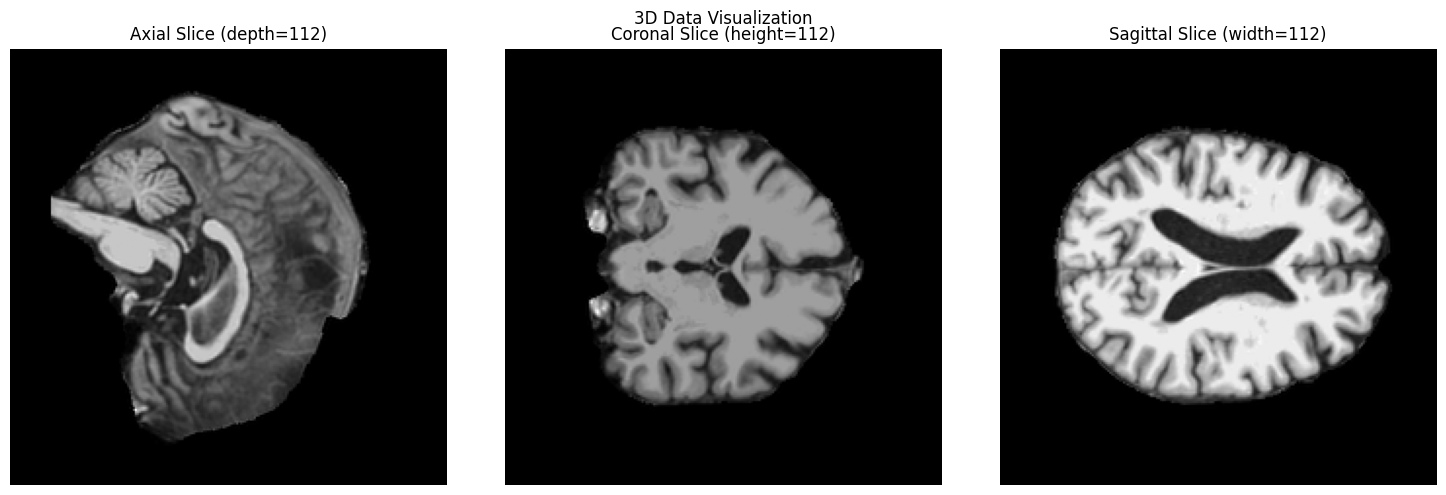

[{'label': 0, 'image': '/mnt/gptdata/liushiyu/datasets/MNI_011_S_0002.nii.gz'},
 {'label': 2, 'image': '/mnt/gptdata/liushiyu/datasets/MNI_011_S_0003.nii.gz'},
 {'label': 1, 'image': '/mnt/gptdata/liushiyu/datasets/MNI_022_S_0004.nii.gz'}]

In [98]:
import glob 
import os 
dataset_path ="/mnt/gptdata/liushiyu/datasets"
target_path = "/mnt/gptdata/liushiyu/latents/adni"
os.makedirs(target_path,exist_ok=True)
all_nifti= sorted(glob.glob(os.path.join(dataset_path,"*nii*")))
all_nifti=[{"image":nifti} for nifti in all_nifti]
from shiyu_utils.maisi_transforms import VAE_Transform
transform = VAE_Transform(is_train=False,random_aug=False,val_patch_size=(224,224,224),spacing_type="fixed",spacing=(1.,1.,1.))
transform = transform.transform_dict["mri"]
def test_transform():
    data = transform(all_nifti[0])["image"]
    print(data.shape)
    from shiyu_utils.plot_3d_data import plot_3d_data
    plot_3d_data(data)
test_transform()
# import pandas as pd 
# df = pd.read_csv("shiyu_utils/ADNIMERGE_03Aug2025.csv")
# org_df = pd.read_csv("shiyu_utils/ADNIMERGE_03Aug2025.csv")
# df = org_df 
# df = df[df["DX_bl"].isin(["CN","AD","LMCI","EMCI"])]
# df = df[df["ORIGPROT"].isin(["ADNI1","ADNI2"])]
# df = df[df["VISCODE"]=="bl"]
# final_df = df[["PTID","DX_bl","ORIGPROT","VISCODE"]]
# all_nifti= sorted(glob.glob(os.path.join(dataset_path,"*nii*")))
# all_nifti_df = pd.DataFrame(all_nifti,columns=["path"])
# # '/mnt/gptdata/liushiyu/datasets/MNI_067_S_2196.nii.gz' => 067_S_2196
# import re 
# all_nifti_df["PTID"] = all_nifti_df["path"].apply(lambda x:re.findall(r"_(\d+_\w+)\.",x)[0])
# all_nifti_df
# # fuse two dfs 
# final_df_merged = pd.merge(final_df,all_nifti_df,on="PTID",how="left")
# # drop na line for merged df 
# final_df_merged = final_df_merged.dropna()
# len(final_df_merged),len(all_nifti),len(final_df)
# final_df_merged.to_csv("3.adni.cfm.merged.csv",index=False)
import pandas as pd 
df = pd.read_csv("3.adni.cfm.merged.csv")[["DX_bl","path"]]
data_list = df.to_dict(orient="records")
data_list_new =[]
label_map = {"CN":0,"AD":2,"EMCI":1,"LMCI":1}
for data in data_list:
    data_list_new.append({
        "label":label_map[data["DX_bl"]],
        "image":data["path"],
    })
data_list_new[:3]

In [ ]:
import monai.data as md 
dataset = md.Dataset(data_list_new,transform=transform)
dataloader = md.DataLoader(dataset,num_workers=8,batch_size=1,shuffle=True)
new_image_root = target_path
from tqdm.notebook import tqdm 
latent_list =[]
autoencoder= autoencoder.cuda()
scale=32
shift=128
forward_func = lambda x: (x*scale+shift).clamp(0,255).to(torch.uint8)
backward_func = lambda x: (x.float()-shift)/scale
# for batch in tqdm(dataloader):
#     data = batch["image"]
#     with torch.no_grad(),torch.cuda.amp.autocast(True):
#         latent = autoencoder.encode_stage_2_inputs(data.cuda().float())
#     latent=latent.cpu().detach()
#     latent= forward_func(latent)
#     latent_list.append(latent)
#     org_full_path = data.meta["filename_or_obj"][0]
#     org_base_name = os.path.basename(org_full_path)
#     new_image_full = os.path.join(new_image_root,org_base_name)
#     new_image = latent
#     torch.save(new_image,new_image_full)

  0%|          | 0/1502 [00:00<?, ?it/s]

/tmp/ipykernel_67417/923186141.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(),torch.cuda.amp.autocast(True):


/tmp/ipykernel_67417/1886349797.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(),torch.cuda.amp.autocast(True):


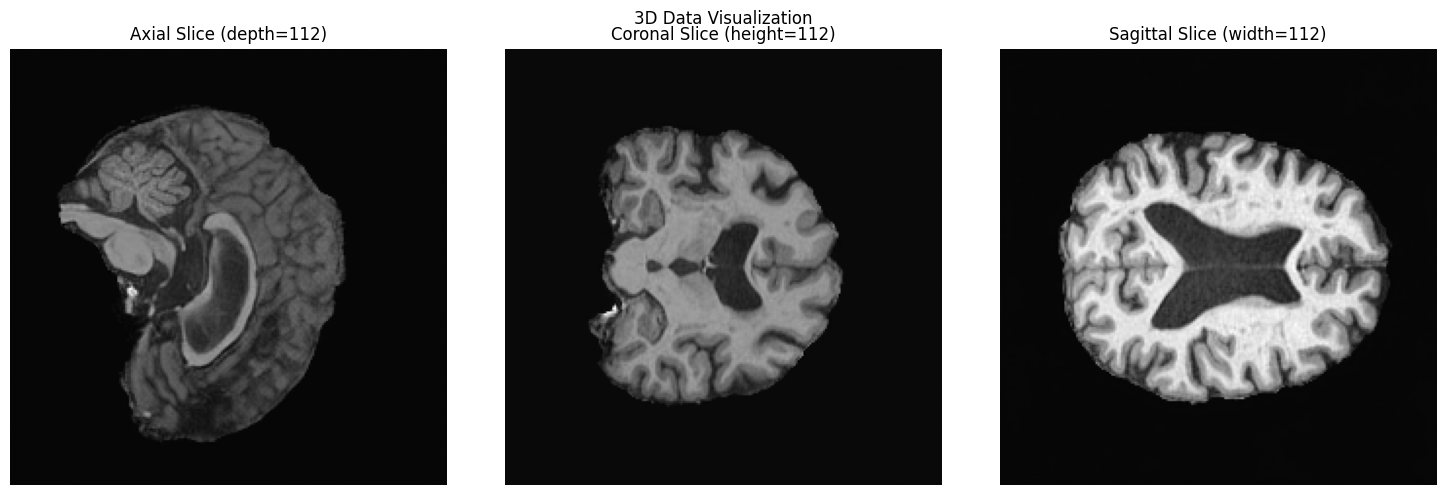

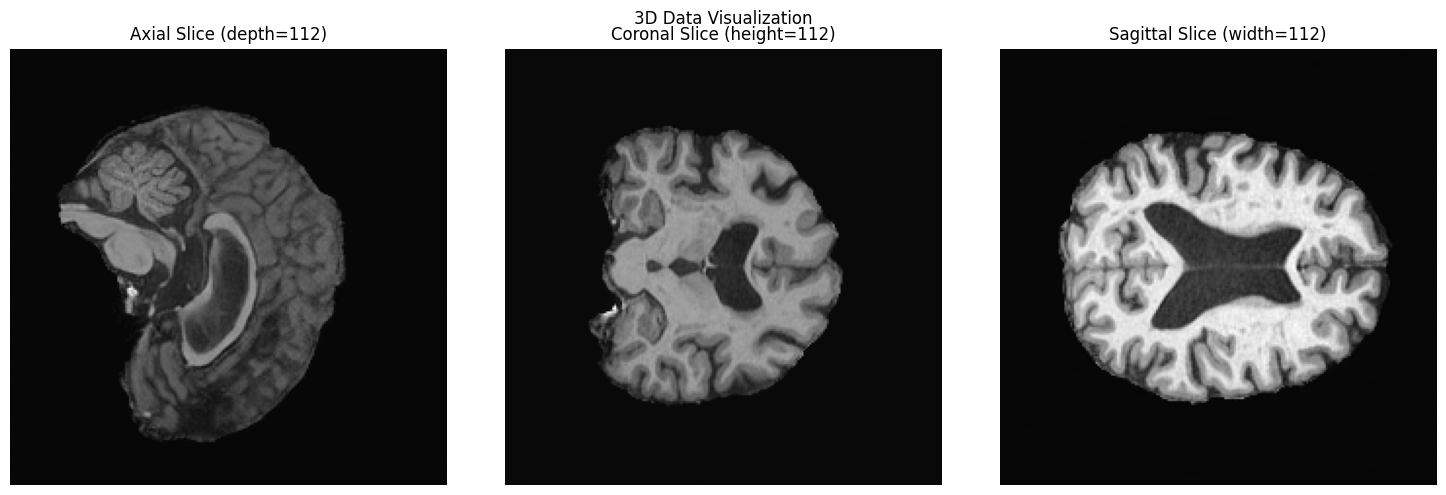

In [ ]:
from shiyu_utils.plot_3d_data import plot_3d_data
scale=32
shift=128
forward_func = lambda x: (x*scale+shift).clamp(0,255)
backward_func = lambda x: (x-shift)/scalex

from monai.bundle import ConfigParser
import torch 
config = ConfigParser()
config.read_config('shiyu_utils/config_maisi3d-rflow.json')
# autoencoder =config.get_parsed_content('autoencoder_def',instanitiate=True)
# autoencoder.load_state_dict(torch.load("models/autoencoder_epoch273.pt"))
# autoencoder.eval()
# autoencoder.cuda()

# with torch.no_grad(),torch.cuda.amp.autocast(True):
#     latent = latent_list[0]
#     recon_org = autoencoder.decode_stage_2_outputs(latent)
#     latent = forward_func(latent).to(torch.uint8).float()
#     latent = backward_func(latent).float()
#     recon_int8 = autoencoder.decode_stage_2_outputs(latent)
#     plot_3d_data(recon_org)
#     plot_3d_data(recon_int8)

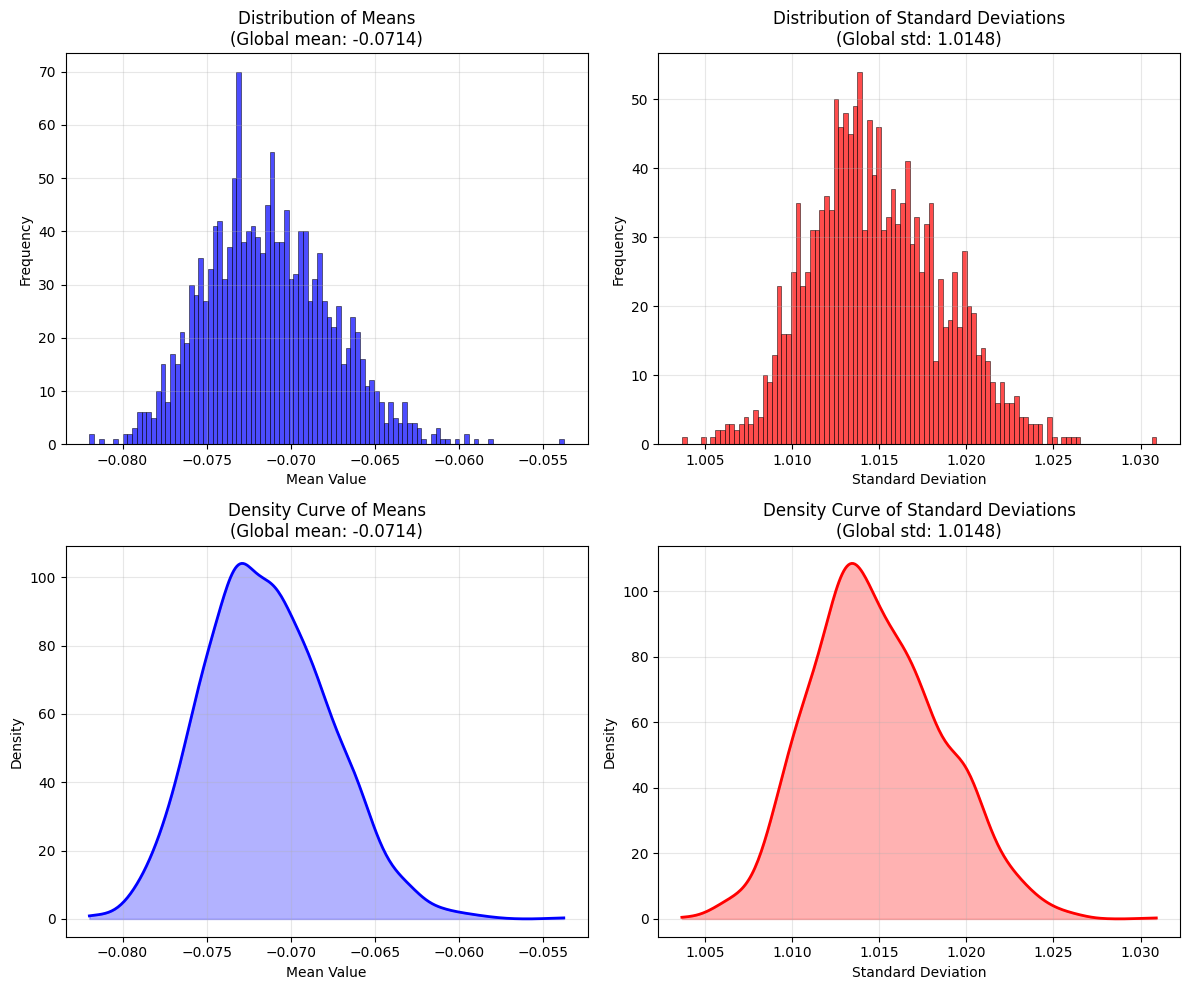

In [ ]:
# import importlib
# import scripts.latent_statistics
# importlib.reload(scripts.latent_statistics)
# latent_list_float=[backward_func(latent) for latent in latent_list]
# from scripts.latent_statistics import analyze_latent_statistics, analyze_multiple_latent_groups
# stats = analyze_latent_statistics(latent_list_float,plot_type="both")